# Salary Prediction & Career Analytics

## Phase 1–6: Data Preparation, Exploratory Analysis, Regression & Statistical Validation

**Objective:** Build a reproducible salary-prediction workflow, starting with data cleaning and exploratory analysis and progressing through linear, polynomial, Ridge and Lasso regression, statistical inference, and linear regression implemented from scratch.

**Dataset:** `Salary_Data.csv`

> **Notebook design:** Each section contains a short explanation followed by only the analysis required to support the project. Repeated checks, exploratory scratch cells, and duplicate outputs have been consolidated.

## 1. Environment Setup

Import the libraries used throughout the notebook. Keeping imports in one place makes the notebook easier to reproduce and avoids repeated imports scattered across later sections.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## 2. Load the Dataset

Load the salary dataset and inspect its dimensions and first few observations. This establishes the starting point before any cleaning is performed.

In [2]:
df = pd.read_csv("/content/Salary_Data.csv")

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
display(df.head())

Dataset shape: 6,704 rows × 6 columns


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


## 3. Initial Data Audit

The initial audit checks the schema, data types, descriptive statistics, missing values, and duplicate rows. These checks identify issues that must be addressed before modeling.

In [3]:
df.info()

display(df.describe(include="all").T)

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": df.isna().mean().mul(100).round(2)
})
display(missing_summary[missing_summary["Missing Count"] > 0])

print(f"Duplicate rows: {df.duplicated().sum():,}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6704 entries, 0 to 6703
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  6702 non-null   float64
 1   Gender               6702 non-null   object 
 2   Education Level      6701 non-null   object 
 3   Job Title            6702 non-null   object 
 4   Years of Experience  6701 non-null   float64
 5   Salary               6699 non-null   float64
dtypes: float64(3), object(3)
memory usage: 314.4+ KB


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,6702.0,NaN,NaN,NaN,33.620859,7.614633,21.0,28.0,32.0,38.0,62.0
Gender,6702,3,Male,3674,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education Level,6701,7,Bachelor's Degree,2267,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Title,6702,193,Software Engineer,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Years of Experience,6701.0,NaN,NaN,NaN,8.094687,6.059003,0.0,3.0,7.0,12.0,34.0
Salary,6699.0,NaN,NaN,NaN,115326.964771,52786.183911,350.0,70000.0,115000.0,160000.0,250000.0


,Missing Count,Missing %
Age,2,0.03
Gender,2,0.03
Education Level,3,0.04
Job Title,2,0.03
Years of Experience,3,0.04
Salary,5,0.07


Duplicate rows: 4,912


### Categorical Value Review

Inspect the main categorical variables for inconsistent labels or unexpected formatting before standardization.

In [4]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()

for column in categorical_columns:
    print(f"\n{column} — {df[column].nunique(dropna=False)} unique values")
    display(df[column].value_counts(dropna=False).head(15))


Gender — 4 unique values


,count
Gender,
Male,3674
Female,3014
Other,14
NaN,2



Education Level — 8 unique values


,count
Education Level,
Bachelor's Degree,2267
Master's Degree,1573
PhD,1368
Bachelor's,756
High School,448
Master's,288
NaN,3
phD,1



Job Title — 194 unique values


,count
Job Title,
Software Engineer,518
Data Scientist,453
Software Engineer Manager,376
Data Analyst,363
Senior Project Engineer,318
Product Manager,313
Full Stack Engineer,309
Marketing Manager,255
Senior Software Engineer,244


## 4. Define the Target and Examine Salary Distribution

`Salary` is the prediction target. Its central tendency, spread, skewness, and potential extreme values are examined before cleaning.

In [5]:
TARGET = "Salary"

salary_summary = df[TARGET].describe()
print(f"Target variable: {TARGET}")
print(f"Skewness: {df[TARGET].skew():.3f}")
display(salary_summary.to_frame("Salary"))

Target variable: Salary
Skewness: 0.057


,Salary
count,6699.000000
mean,115326.964771
std,52786.183911
min,350.000000
25%,70000.000000
50%,115000.000000
75%,160000.000000
max,250000.000000


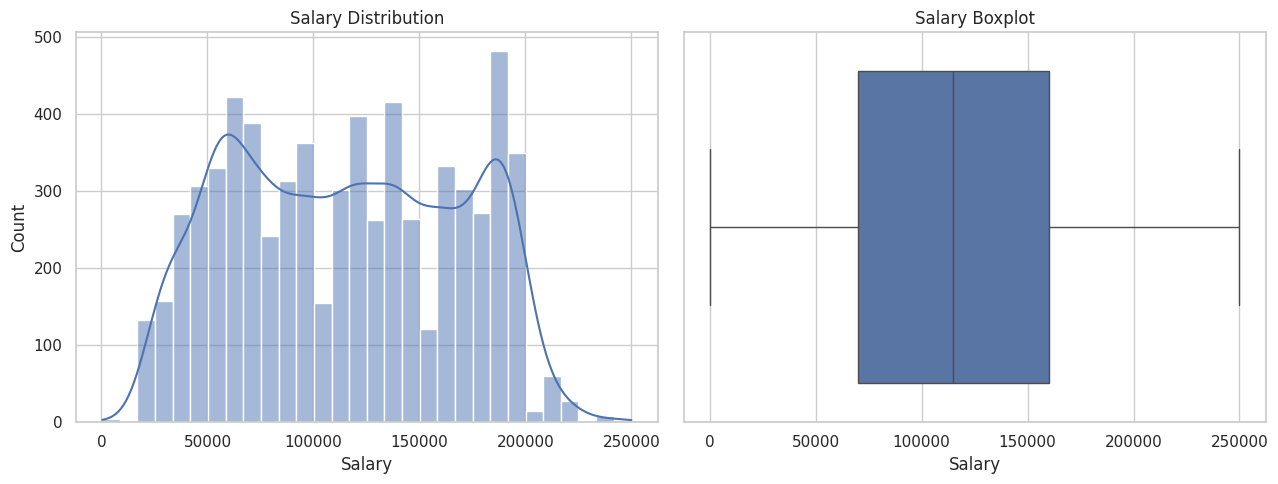

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Salary Distribution")
axes[0].set_xlabel("Salary")

sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("Salary Boxplot")
axes[1].set_xlabel("Salary")

plt.tight_layout()
plt.show()

## 5. Identify Numerical and Categorical Features

Separate numerical and categorical variables so that the appropriate preprocessing and exploratory techniques can be applied later.

In [7]:
numeric_features = df.select_dtypes(include=np.number).columns.tolist()
categorical_features = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Age', 'Years of Experience', 'Salary']
Categorical features: ['Gender', 'Education Level', 'Job Title']


## 6. Relationship Between Experience and Salary

Years of experience is expected to be an important predictor of salary. Examine its relationship with the target using both correlation and a fitted trend line.

Correlation between experience and salary: 0.809


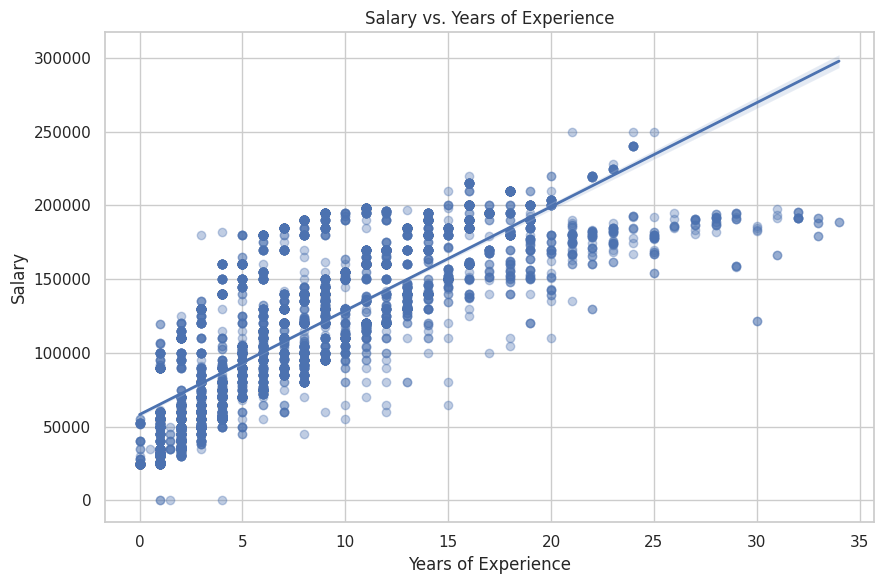

In [8]:
experience_salary_corr = df[["Years of Experience", TARGET]].corr().iloc[0, 1]
print(f"Correlation between experience and salary: {experience_salary_corr:.3f}")

plt.figure(figsize=(9, 6))
sns.regplot(
    data=df,
    x="Years of Experience",
    y=TARGET,
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 2}
)
plt.title("Salary vs. Years of Experience")
plt.tight_layout()
plt.show()

## 7. Job Title and Education-Level Analysis

Salary can vary substantially across occupations and education levels. Summaries below focus on groups with enough observations to make comparisons more meaningful.

In [9]:
job_summary = (
    df.groupby("Job Title")[TARGET]
      .agg(Count="count", Mean="mean", Median="median")
      .sort_values("Mean", ascending=False)
)

education_summary = (
    df.groupby("Education Level")[TARGET]
      .agg(Count="count", Mean="mean", Median="median", Std="std")
      .sort_values("Mean", ascending=False)
)

display(job_summary.head(15))
display(education_summary)

,Count,Mean,Median
Job Title,,,
CEO,1,250000.000000,250000.0
Chief Technology Officer,1,250000.000000,250000.0
Chief Data Officer,1,220000.000000,220000.0
Director of Data Science,57,204561.403509,210000.0
Director,1,200000.000000,200000.0
VP of Finance,1,200000.000000,200000.0
Operations Director,1,190000.000000,190000.0
VP of Operations,1,190000.000000,190000.0
Director of Human Resources,2,187500.000000,187500.0


,Count,Mean,Median,Std
Education Level,,,,
PhD,1368,165684.828947,170000.0,34330.096351
Master's,288,157604.166667,177500.0,39864.267750
Master's Degree,1572,125075.333969,122000.0,38732.484980
Bachelor's,756,124767.658730,130000.0,46697.558848
phD,1,120000.000000,120000.0,NaN
Bachelor's Degree,2265,85174.886093,75000.0,38387.390981
High School,448,36706.694196,30000.0,22549.129999


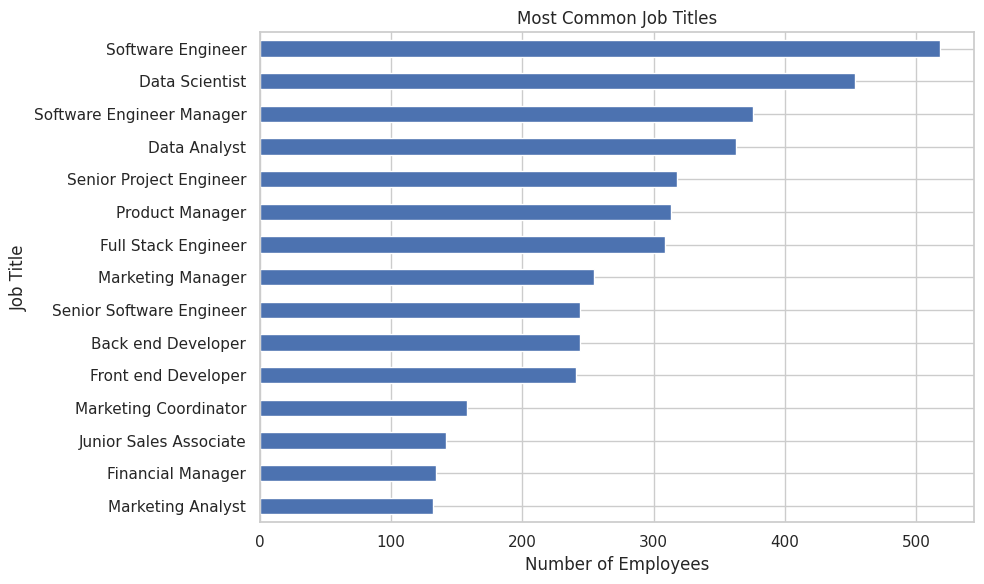

In [10]:
top_titles = df["Job Title"].value_counts().head(15).sort_values()

plt.figure(figsize=(10, 6))
top_titles.plot(kind="barh")
plt.title("Most Common Job Titles")
plt.xlabel("Number of Employees")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()

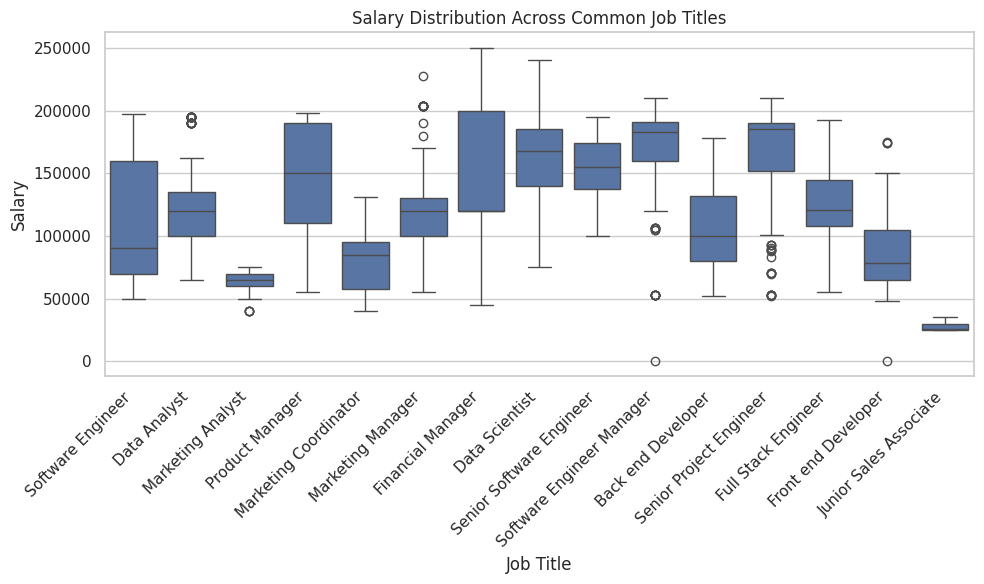

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df[df["Job Title"].isin(top_titles.index)],
    x="Job Title",
    y=TARGET
)
plt.title("Salary Distribution Across Common Job Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

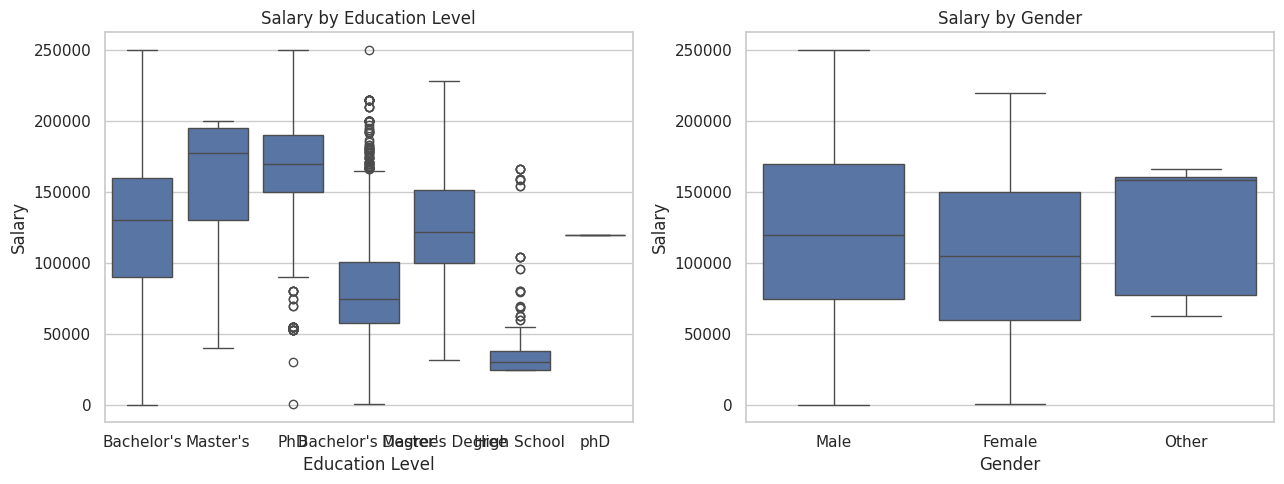

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(data=df, x="Education Level", y=TARGET, ax=axes[0])
axes[0].set_title("Salary by Education Level")

sns.boxplot(data=df, x="Gender", y=TARGET, ax=axes[1])
axes[1].set_title("Salary by Gender")

plt.tight_layout()
plt.show()

## 8. Data Cleaning

Cleaning is deliberately separated from exploratory analysis. Duplicate observations are removed, the target is required to be present, categorical labels are standardized, and clearly implausible salary values are flagged and removed.

The salary threshold below follows the quality-control rule used in the original notebook: salaries below 1,000 are treated as implausible annual salary records.

In [13]:
original_rows = len(df)

# Remove exact duplicate records.
df = df.drop_duplicates().reset_index(drop=True)

# The target must be available for supervised learning.
df = df.dropna(subset=[TARGET]).copy()

# Standardize categorical labels and whitespace.
education_mapping = {
    "Bachelor's Degree": "Bachelor's",
    "Master's Degree": "Master's",
    "phD": "PhD"
}
df["Education Level"] = df["Education Level"].replace(education_mapping)

for column in ["Gender", "Education Level", "Job Title"]:
    df[column] = df[column].astype("string").str.strip()

# Fill missing education labels explicitly.
df["Education Level"] = df["Education Level"].fillna("Unknown")

# Flag and remove clearly implausible salary observations.
salary_quality_mask = df[TARGET] < 1000
salary_anomalies = df.loc[salary_quality_mask].copy()
df = df.loc[~salary_quality_mask].copy()

print(f"Original rows: {original_rows:,}")
print(f"Final rows:    {len(df):,}")
print(f"Rows removed:  {original_rows - len(df):,}")
print(f"Salary anomalies removed: {len(salary_anomalies):,}")

Original rows: 6,704
Final rows:    1,784
Rows removed:  4,920
Salary anomalies removed: 4


### Post-cleaning Validation

Confirm that the cleaned dataset contains no missing values in the modeled fields and no duplicate records.

In [14]:
validation = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Duplicate rows",
        "Missing values",
        "Minimum salary",
        "Maximum salary"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.duplicated().sum(),
        int(df.isna().sum().sum()),
        df[TARGET].min(),
        df[TARGET].max()
    ]
})
display(validation)

,Metric,Value
0,Rows,1784.0
1,Columns,6.0
2,Duplicate rows,1.0
3,Missing values,0.0
4,Minimum salary,25000.0
5,Maximum salary,250000.0


## 9. Final Exploratory Analysis

With the data cleaned, perform the core EDA used to motivate the regression models. The numerical correlation matrix gives a compact view of linear relationships among the continuous variables.

,Age,Years of Experience,Salary
Age,1.000000,0.936067,0.766988
Years of Experience,0.936067,1.000000,0.818979
Salary,0.766988,0.818979,1.000000


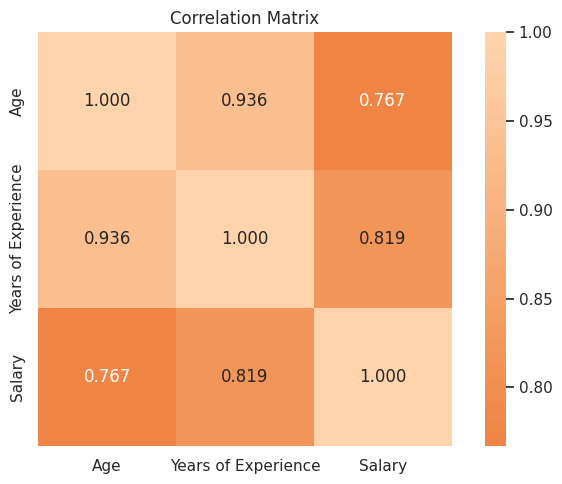

In [15]:
numeric_cols = ["Age", "Years of Experience", "Salary"]
corr_matrix = df[numeric_cols].corr()

display(corr_matrix)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

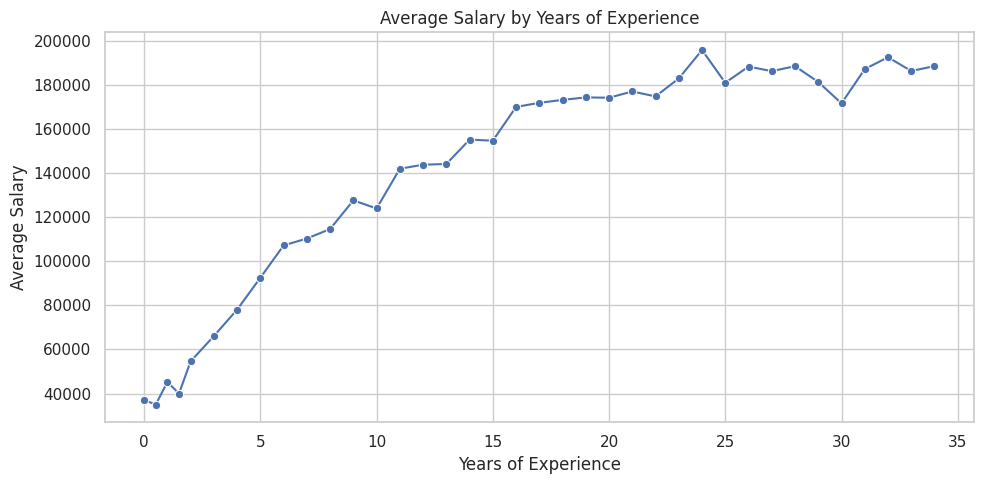

In [16]:
experience_salary = (
    df.groupby("Years of Experience")[TARGET]
      .agg(Count="count", Mean="mean", Median="median")
      .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=experience_salary,
    x="Years of Experience",
    y="Mean",
    marker="o"
)
plt.title("Average Salary by Years of Experience")
plt.ylabel("Average Salary")
plt.tight_layout()
plt.show()

## 10. Save the Cleaned Dataset

Save the final analysis-ready dataset so that later phases can be reproduced without repeating the cleaning process.

In [17]:
cleaned_file = "/content/salary_data_cleaned.csv"
df.to_csv(cleaned_file, index=False)

print(f"Saved cleaned dataset: {cleaned_file}")
print(f"File exists: {os.path.exists(cleaned_file)}")

Saved cleaned dataset: /content/salary_data_cleaned.csv
File exists: True


# Phase 2 — Feature Engineering & Dataset Preparation

Separate predictors from the target, create a reproducible train/test split, and build a preprocessing pipeline. Numerical variables are standardized and categorical variables are one-hot encoded.

In [18]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

numerical_features = ["Age", "Years of Experience"]
categorical_features = ["Gender", "Education Level", "Job Title"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print(f"Training observations: {len(X_train):,}")
print(f"Testing observations:  {len(X_test):,}")

Training observations: 1,427
Testing observations:  357


In [19]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape: ", X_test_processed.shape)
print("Transformed features:    ", len(feature_names))

Processed training shape: (1427, 187)
Processed testing shape:  (357, 187)
Transformed features:     187


# Phase 3 — Baseline Multiple Linear Regression

Train a baseline multiple linear regression model using the same preprocessing pipeline used for all regularized models. Evaluation uses MAE, RMSE, and R² on both training and test sets.

In [20]:
linear_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_model.fit(X_train, y_train)

y_train_pred = linear_model.predict(X_train)
y_test_pred = linear_model.predict(X_test)

baseline_metrics = pd.DataFrame({
    "Split": ["Train", "Test"],
    "MAE": [
        mean_absolute_error(y_train, y_train_pred),
        mean_absolute_error(y_test, y_test_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        np.sqrt(mean_squared_error(y_test, y_test_pred))
    ],
    "R²": [
        r2_score(y_train, y_train_pred),
        r2_score(y_test, y_test_pred)
    ]
})

display(baseline_metrics.round(3))

,Split,MAE,RMSE,R²
0,Train,13188.704,18736.981,0.863
1,Test,14857.078,20633.780,0.853


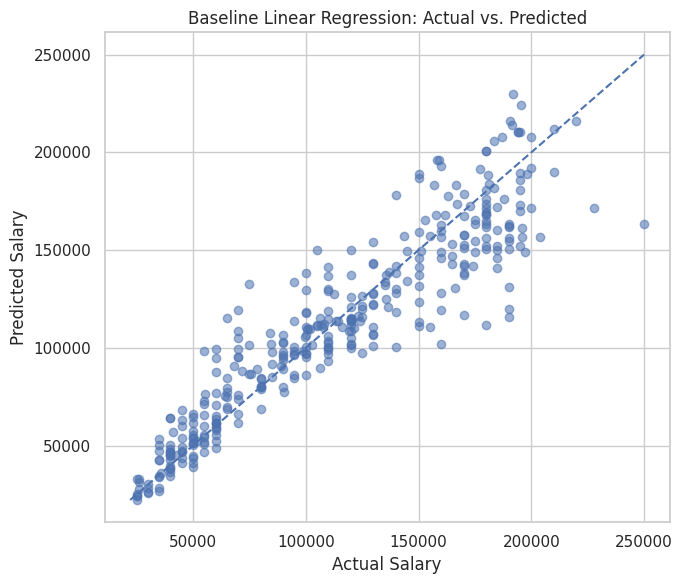

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_test_pred, alpha=0.55)

lims = [min(y_test.min(), y_test_pred.min()), max(y_test.max(), y_test_pred.max())]
plt.plot(lims, lims, linestyle="--")

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Baseline Linear Regression: Actual vs. Predicted")
plt.tight_layout()
plt.show()

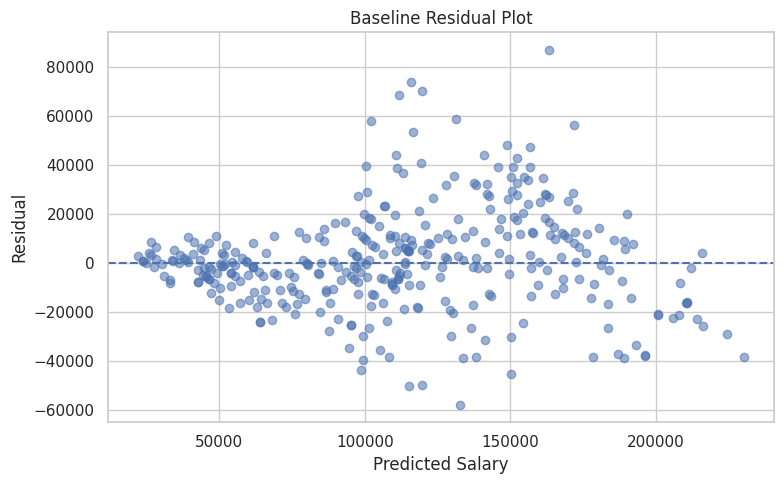

In [22]:
residuals_test = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pred, residuals_test, alpha=0.55)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Salary")
plt.ylabel("Residual")
plt.title("Baseline Residual Plot")
plt.tight_layout()
plt.show()

### 5-Fold Cross-Validation

Cross-validation provides a more stable estimate of generalization performance than relying on a single train/test split.

In [23]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    linear_model,
    X,
    y,
    cv=kfold,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    }
)

linear_cv_summary = pd.DataFrame({
    "Metric": ["R²", "MAE", "RMSE"],
    "Mean": [
        cv_results["test_R2"].mean(),
        -cv_results["test_MAE"].mean(),
        -cv_results["test_RMSE"].mean()
    ],
    "Std": [
        cv_results["test_R2"].std(),
        cv_results["test_MAE"].std(),
        cv_results["test_RMSE"].std()
    ]
})

display(linear_cv_summary.round(3))

,Metric,Mean,Std
0,R²,0.840,0.010
1,MAE,15033.114,280.876
2,RMSE,20483.694,578.347


# Phase 4 — Polynomial Regression

Polynomial features allow the model to capture nonlinear relationships among the numerical predictors. Categorical variables remain one-hot encoded.

In [24]:
polynomial_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("poly", PolynomialFeatures(degree=2, include_bias=False)),
            ("scale", StandardScaler())
        ]), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

polynomial_model = Pipeline([
    ("preprocessor", polynomial_preprocessor),
    ("model", LinearRegression())
])

polynomial_model.fit(X_train, y_train)
y_poly_pred = polynomial_model.predict(X_test)

polynomial_test = {
    "MAE": mean_absolute_error(y_test, y_poly_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_poly_pred)),
    "R²": r2_score(y_test, y_poly_pred)
}

display(pd.DataFrame([polynomial_test], index=["Polynomial Regression"]).round(3))

,MAE,RMSE,R²
Polynomial Regression,12993.897,18284.479,0.885


In [25]:
poly_cv = cross_validate(
    polynomial_model,
    X,
    y,
    cv=kfold,
    scoring={
        "R2": "r2",
        "MAE": "neg_mean_absolute_error",
        "RMSE": "neg_root_mean_squared_error"
    }
)

print(f"5-fold CV R²:   {poly_cv['test_R2'].mean():.4f}")
print(f"5-fold CV MAE:  {-poly_cv['test_MAE'].mean():,.2f}")
print(f"5-fold CV RMSE: {-poly_cv['test_RMSE'].mean():,.2f}")

5-fold CV R²:   0.8710
5-fold CV MAE:  13,366.79
5-fold CV RMSE: 18,404.23


# Phase 5 — Ridge and Lasso Regression

Ridge and Lasso introduce L2 and L1 regularization respectively. Hyperparameter search is performed using cross-validation rather than selecting the penalty strength from the test set.

In [26]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid={"model__alpha": np.logspace(-3, 3, 13)},
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_
y_ridge_pred = best_ridge.predict(X_test)

print("Best Ridge alpha:", ridge_grid.best_params_["model__alpha"])

Best Ridge alpha: 0.31622776601683794


In [27]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=10000))
])

lasso_grid = GridSearchCV(
    lasso_pipeline,
    param_grid={"model__alpha": np.logspace(-3, 3, 13)},
    cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)
best_lasso = lasso_grid.best_estimator_
y_lasso_pred = best_lasso.predict(X_test)

print("Best Lasso alpha:", lasso_grid.best_params_["model__alpha"])

Best Lasso alpha: 3.1622776601683795


In [28]:
model_comparison = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": mean_absolute_error(y_test, y_test_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_test_pred)),
        "R²": r2_score(y_test, y_test_pred)
    },
    {
        "Model": "Polynomial Regression",
        "MAE": mean_absolute_error(y_test, y_poly_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_poly_pred)),
        "R²": r2_score(y_test, y_poly_pred)
    },
    {
        "Model": "Ridge Regression",
        "MAE": mean_absolute_error(y_test, y_ridge_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_ridge_pred)),
        "R²": r2_score(y_test, y_ridge_pred)
    },
    {
        "Model": "Lasso Regression",
        "MAE": mean_absolute_error(y_test, y_lasso_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_lasso_pred)),
        "R²": r2_score(y_test, y_lasso_pred)
    }
]).sort_values("RMSE")

display(model_comparison.round(3))

,Model,MAE,RMSE,R²
1,Polynomial Regression,12993.897,18284.479,0.885
2,Ridge Regression,14862.991,20556.961,0.854
3,Lasso Regression,14857.435,20604.931,0.854
0,Linear Regression,14857.078,20633.780,0.853


## Lasso Feature Selection

Lasso can shrink weak coefficients exactly to zero. Inspect the transformed feature space to identify the predictors retained by the fitted model.

In [29]:
lasso_estimator = best_lasso.named_steps["model"]
lasso_feature_names = best_lasso.named_steps["preprocessor"].get_feature_names_out()

lasso_features = pd.DataFrame({
    "Feature": lasso_feature_names,
    "Coefficient": lasso_estimator.coef_
})

nonzero_features = (
    lasso_features[lasso_features["Coefficient"] != 0]
    .assign(Absolute_Coefficient=lambda x: x["Coefficient"].abs())
    .sort_values("Absolute_Coefficient", ascending=False)
)

display(nonzero_features.head(25))

,Feature,Coefficient,Absolute_Coefficient
16,cat__Job Title_Chief Data Officer,85913.075529,85913.075529
17,cat__Job Title_Chief Technology Officer,80252.788212,80252.788212
35,cat__Job Title_Director of Data Science,69045.241891,69045.241891
115,cat__Job Title_Research Director,65922.399218,65922.399218
99,cat__Job Title_Marketing Director,64878.700185,64878.700185
27,cat__Job Title_Data Scientist,62348.736422,62348.736422
109,cat__Job Title_Product Manager,59945.142048,59945.142048
116,cat__Job Title_Research Scientist,54660.855461,54660.855461
184,cat__Job Title_VP of Finance,51311.523020,51311.523020
25,cat__Job Title_Data Analyst,49327.610891,49327.610891


# Phase 6 — Statistical Analysis with OLS

The predictive models above focus on generalization. Ordinary Least Squares (OLS) is used here for statistical inference: coefficient estimates, uncertainty, significance, multicollinearity diagnostics, and residual assumptions.

Categorical variables are one-hot encoded with one reference category dropped.

In [30]:
df_stats = df.dropna().copy()

df_stats_encoded = pd.get_dummies(
    df_stats,
    columns=["Gender", "Education Level", "Job Title"],
    drop_first=True
).astype(float)

X_stats = df_stats_encoded.drop(columns=[TARGET])
y_stats = df_stats_encoded[TARGET]

X_stats_const = sm.add_constant(X_stats)

ols_model = sm.OLS(y_stats, X_stats_const).fit()

print(f"R²: {ols_model.rsquared:.4f}")
print(f"Adjusted R²: {ols_model.rsquared_adj:.4f}")

R²: 0.8660
Adjusted R²: 0.8492


/tmp/ipykernel_1315/1360923812.py:14: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  ols_model = sm.OLS(y_stats, X_stats_const).fit()


In [31]:
significance_table = pd.DataFrame({
    "Feature": ols_model.params.index,
    "Coefficient": ols_model.params.values,
    "Std_Error": ols_model.bse.values,
    "t_value": ols_model.tvalues.values,
    "p_value": ols_model.pvalues.values
}).sort_values("p_value")

display(significance_table.head(25).round(4))

,Feature,Coefficient,Std_Error,t_value,p_value
2,Years of Experience,2660.2360,225.8299,11.7798,0.0000
1,Age,1761.6500,188.5425,9.3435,0.0000
6,Education Level_Master's,6606.4264,1420.1157,4.6520,0.0000
5,Education Level_High School,-11807.9616,2952.2715,-3.9996,0.0001
36,Job Title_Director of Data Science,69179.7292,21454.8482,3.2244,0.0013
15,Job Title_CEO,90085.5811,28288.9348,3.1845,0.0015
16,Job Title_Chief Data Officer,88823.3129,28297.8854,3.1389,0.0017
122,Job Title_Research Director,64268.6111,21067.5148,3.0506,0.0023
104,Job Title_Marketing Director,65512.2797,21619.3345,3.0303,0.0025
28,Job Title_Data Scientist,60032.7981,20153.8376,2.9787,0.0029


## Multicollinearity — Variance Inflation Factor (VIF)

VIF measures how strongly each predictor is explained by the other predictors. The focus here is on the continuous variables because the one-hot encoded job-title features can produce a large, less interpretable VIF table.

In [32]:
vif_data = pd.DataFrame({
    "Feature": X_stats_const.columns,
    "VIF": [
        variance_inflation_factor(X_stats_const.values, i)
        for i in range(X_stats_const.shape[1])
    ]
})

display(
    vif_data[vif_data["Feature"].isin(["const", "Age", "Years of Experience"])]
)

/tmp/ipykernel_1315/972791732.py:4: UserWarning: The design matrix is poorly conditioned (condition number=1.73e+15). VIF calculations may be numerically unstable.
  variance_inflation_factor(X_stats_const.values, i)
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influenc

,Feature,VIF
0,const,1.000000
1,Age,10.744711
2,Years of Experience,10.700862


## Residual Diagnostics

Inspect residual-versus-fitted values, the residual distribution, and a Q-Q plot. These diagnostics help assess linearity, unusual variance patterns, and approximate normality of residuals.

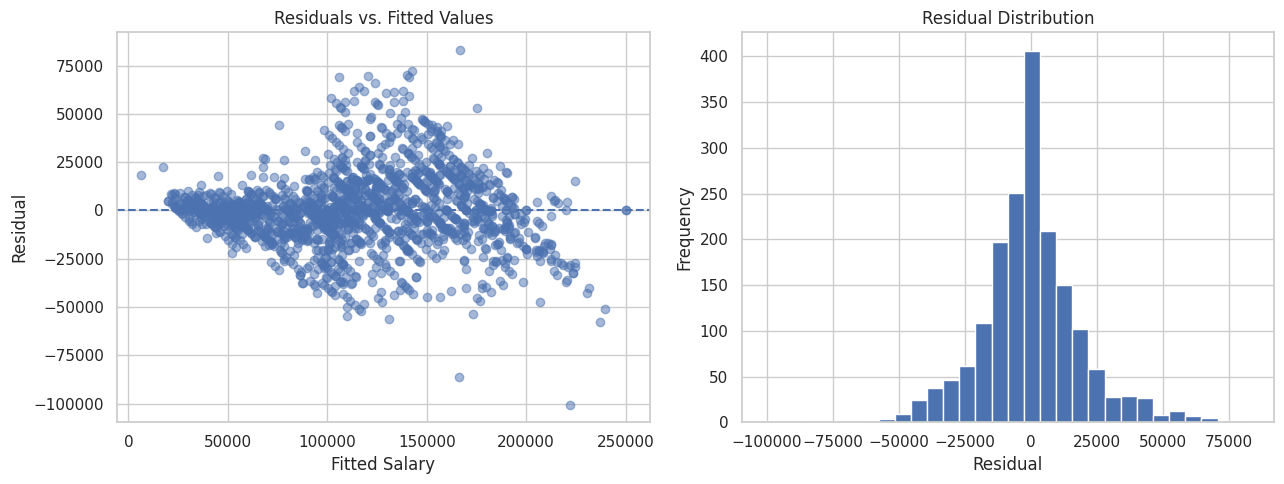

In [33]:
y_fitted = ols_model.fittedvalues
ols_residuals = ols_model.resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_fitted, ols_residuals, alpha=0.5)
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Fitted Salary")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs. Fitted Values")

axes[1].hist(ols_residuals, bins=30)
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

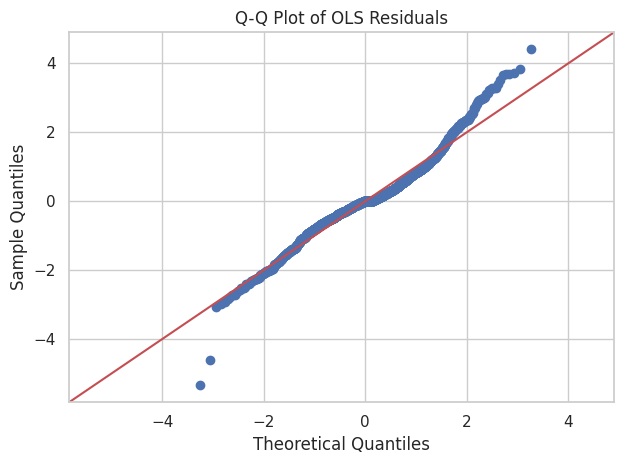

In [34]:
sm.qqplot(ols_residuals, line="45", fit=True)
plt.title("Q-Q Plot of OLS Residuals")
plt.tight_layout()
plt.show()

In [35]:
bp_stat, bp_pvalue, _, _ = het_breuschpagan(
    ols_residuals,
    X_stats_const
)

print(f"Breusch–Pagan LM statistic: {bp_stat:.4f}")
print(f"Breusch–Pagan p-value:      {bp_pvalue:.4g}")

Breusch–Pagan LM statistic: 641.0938
Breusch–Pagan p-value:      6.39e-48


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/diagnostic.py:1217: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  resols = OLS(y, x).fit()


## Robust Standard Errors

If heteroskedasticity is present, conventional OLS standard errors can be unreliable. HC3 robust standard errors provide a more conservative inference under heteroskedasticity.

In [36]:
ols_hc3 = ols_model.get_robustcov_results(cov_type="HC3", use_t=False)

robust_table = pd.DataFrame({
    "Feature": X_stats_const.columns,
    "Coefficient": ols_hc3.params,
    "Robust_SE": ols_hc3.bse,
    "Robust_p_value": ols_hc3.pvalues
}).sort_values("Robust_p_value")

display(robust_table.head(25).round(4))

/usr/local/lib/python3.13/dist-packages/statsmodels/regression/linear_model.py:2257: RuntimeWarning: divide by zero encountered in divide
  self.het_scale = (self.wresid / (1 - h)) ** 2


,Feature,Coefficient,Robust_SE,Robust_p_value
0,const,3162.2170,inf,1.0
1,Age,1761.6500,inf,1.0
2,Years of Experience,2660.2360,inf,1.0
3,Gender_Male,2163.8041,inf,1.0
4,Gender_Other,-10961.2064,inf,1.0
5,Education Level_High School,-11807.9616,inf,1.0
6,Education Level_Master's,6606.4264,inf,1.0
7,Education Level_PhD,5774.2918,inf,1.0
8,Education Level_Unknown,14243.8890,inf,1.0
9,Job Title_Accountant,-13414.3100,inf,1.0


## Leverage Diagnostics

Leverage identifies observations with unusual predictor combinations. Rather than repeatedly printing the same diagnostic, report the key dimensions and inspect observations exceeding a high leverage threshold.

In [37]:
influence = ols_model.get_influence()
leverage = influence.hat_matrix_diag

n = X_stats_const.shape[0]
p = X_stats_const.shape[1]
leverage_threshold = 2 * p / n

high_leverage = np.where(leverage >= leverage_threshold)[0]

print(f"Observations (n): {n}")
print(f"Parameters (p):   {p}")
print(f"Average leverage: {p / n:.6f}")
print(f"Threshold (2p/n): {leverage_threshold:.6f}")
print(f"High-leverage observations: {len(high_leverage)}")

if len(high_leverage):
    display(df_stats.iloc[high_leverage].head(20))

Observations (n): 1784
Parameters (p):   200
Average leverage: 0.112108
Threshold (2p/n): 0.224215
High-leverage observations: 216


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
4,52.0,Male,Master's,Director,20.0,200000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0
11,48.0,Female,Bachelor's,HR Manager,18.0,140000.0
14,27.0,Male,Bachelor's,Customer Service Rep,2.0,40000.0
17,39.0,Male,PhD,Senior Engineer,12.0,115000.0
18,25.0,Female,Bachelor's,Data Entry Clerk,0.0,35000.0
20,34.0,Female,Master's,Business Analyst,5.0,80000.0
21,47.0,Male,Master's,VP of Operations,19.0,190000.0
22,30.0,Male,Bachelor's,IT Support,2.0,50000.0


# Linear Regression From Scratch

This section verifies the core linear-regression calculations independently of scikit-learn.

Two optimization approaches are demonstrated:

1. **Normal Equation:** a closed-form least-squares solution.
2. **Gradient Descent:** iterative optimization of the mean squared error.

The processed feature matrix from Phase 2 is reused to ensure the comparison is consistent with the baseline model.

## 1. Prepare the Design Matrix

Convert the sparse preprocessed matrix to dense NumPy arrays, add an intercept column, and prepare the target vectors.

In [38]:
X_train_np = np.asarray(X_train_processed.toarray(), dtype=float)
X_test_np = np.asarray(X_test_processed.toarray(), dtype=float)
y_train_np = np.asarray(y_train, dtype=float).ravel()
y_test_np = np.asarray(y_test, dtype=float).ravel()

X_train_scratch = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_test_scratch = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

print("Training design matrix:", X_train_scratch.shape)
print("Testing design matrix: ", X_test_scratch.shape)

Training design matrix: (1427, 188)
Testing design matrix:  (357, 188)


## 2. Normal Equation

For ordinary least squares, the coefficient vector satisfies:

$$
\beta = (X^T X)^{-1}X^T y
$$

In implementation, `np.linalg.solve` is used instead of explicitly computing the matrix inverse.

In [39]:
XTX = X_train_scratch.T @ X_train_scratch
XTy = X_train_scratch.T @ y_train_np

beta_normal = np.linalg.solve(XTX, XTy)

y_train_pred_normal = X_train_scratch @ beta_normal
y_test_pred_normal = X_test_scratch @ beta_normal

print("Number of parameters:", len(beta_normal))

Number of parameters: 188


## 3. Evaluate the Normal-Equation Solution

In [40]:
def regression_metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred) ** 2)
    return {
        "MAE": np.mean(np.abs(y_true - y_pred)),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R²": 1 - np.sum((y_true - y_pred) ** 2) /
              np.sum((y_true - np.mean(y_true)) ** 2)
    }

normal_results = pd.DataFrame([
    {"Split": "Train", **regression_metrics(y_train_np, y_train_pred_normal)},
    {"Split": "Test", **regression_metrics(y_test_np, y_test_pred_normal)}
])

display(normal_results.round(3))

,Split,MAE,MSE,RMSE,R²
0,Train,13188.56,3.510745e+08,18736.981,0.863
1,Test,17001.67,6.622945e+08,25735.084,0.772


## 4. Numerical Conditioning and Stable Least Squares

The condition number illustrates the numerical sensitivity of the normal equation. A least-squares solver provides a numerically stable alternative when the design matrix is poorly conditioned.

In [41]:
cond_X = np.linalg.cond(X_train_scratch)
cond_XTX = np.linalg.cond(XTX)

print(f"cond(X):     {cond_X:.6e}")
print(f"cond(XᵀX):   {cond_XTX:.6e}")
print(f"cond(X)^2:   {cond_X**2:.6e}")

beta_lstsq, _, rank, _ = np.linalg.lstsq(
    X_train_scratch,
    y_train_np,
    rcond=None
)

y_test_pred_lstsq = X_test_scratch @ beta_lstsq

stable_results = regression_metrics(y_test_np, y_test_pred_lstsq)

print(f"Design-matrix rank: {rank}")
display(pd.DataFrame([stable_results], index=["Least Squares"]).round(3))

cond(X):     8.479540e+16
cond(XᵀX):   1.102415e+18
cond(X)^2:   7.190260e+33
Design-matrix rank: 184


,MAE,MSE,RMSE,R²
Least Squares,14853.649,4.256872e+08,20632.188,0.853


## 5. Gradient Descent From Scratch

Gradient descent minimizes the mean squared error iteratively:

$$
\theta \leftarrow \theta - \eta \frac{2}{n}X^T(X\theta-y)
$$

The feature matrix is already standardized by the preprocessing pipeline, which makes a single learning rate more practical.

In [42]:
def gradient_descent(X, y, learning_rate=0.01, n_iterations=1200):
    n_samples, n_features = X.shape
    theta = np.zeros(n_features)
    loss_history = []

    for _ in range(n_iterations):
        predictions = X @ theta
        error = predictions - y
        gradient = (2 / n_samples) * (X.T @ error)

        theta -= learning_rate * gradient
        loss_history.append(np.mean(error ** 2))

    return theta, loss_history

In [43]:
X_train_gd = np.c_[np.ones(X_train_np.shape[0]), X_train_np]
X_test_gd = np.c_[np.ones(X_test_np.shape[0]), X_test_np]

theta_gd, loss_history = gradient_descent(
    X_train_gd,
    y_train_np,
    learning_rate=0.01,
    n_iterations=1200
)

y_train_pred_gd = X_train_gd @ theta_gd
y_test_pred_gd = X_test_gd @ theta_gd

gd_results = pd.DataFrame([
    {"Split": "Train", **regression_metrics(y_train_np, y_train_pred_gd)},
    {"Split": "Test", **regression_metrics(y_test_np, y_test_pred_gd)}
])

display(gd_results.round(3))

,Split,MAE,MSE,RMSE,R²
0,Train,17570.897,5.274250e+08,22965.736,0.795
1,Test,18285.011,5.549953e+08,23558.338,0.809


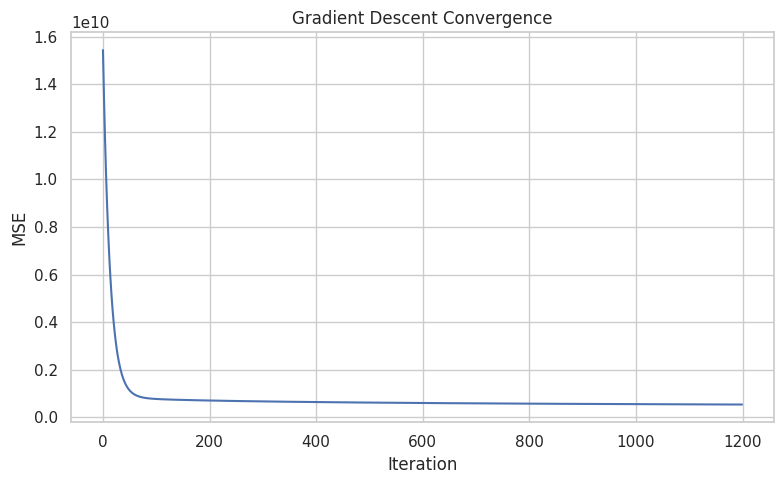

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("MSE")
plt.title("Gradient Descent Convergence")
plt.tight_layout()
plt.show()

# Final Model Comparison

The table below brings together the main predictive approaches. This provides a concise end point for the notebook and makes the modeling results easy to compare.

In [45]:
scratch_comparison = pd.DataFrame([
    {"Model": "Linear Regression — sklearn", **regression_metrics(y_test_np, y_test_pred)},
    {"Model": "Linear Regression — Normal Equation", **regression_metrics(y_test_np, y_test_pred_normal)},
    {"Model": "Linear Regression — Least Squares", **regression_metrics(y_test_np, y_test_pred_lstsq)},
    {"Model": "Linear Regression — Gradient Descent", **regression_metrics(y_test_np, y_test_pred_gd)},
    {"Model": "Polynomial Regression", **regression_metrics(y_test_np, y_poly_pred)},
    {"Model": "Ridge Regression", **regression_metrics(y_test_np, y_ridge_pred)},
    {"Model": "Lasso Regression", **regression_metrics(y_test_np, y_lasso_pred)}
]).sort_values("RMSE")

display(scratch_comparison.round(3))

,Model,MAE,MSE,RMSE,R²
4,Polynomial Regression,12993.897,3.343222e+08,18284.479,0.885
5,Ridge Regression,14862.991,4.225887e+08,20556.961,0.854
6,Lasso Regression,14857.435,4.245632e+08,20604.931,0.854
2,Linear Regression — Least Squares,14853.649,4.256872e+08,20632.188,0.853
0,Linear Regression — sklearn,14857.078,4.257529e+08,20633.780,0.853
3,Linear Regression — Gradient Descent,18285.011,5.549953e+08,23558.338,0.809
1,Linear Regression — Normal Equation,17001.670,6.622945e+08,25735.084,0.772


# Conclusion

This notebook established an end-to-end salary prediction workflow:

- cleaned and validated the raw salary data,
- explored the relationships between salary and key demographic/career variables,
- built a reproducible preprocessing pipeline,
- compared linear, polynomial, Ridge and Lasso regression,
- used cross-validation and hyperparameter tuning,
- examined statistical significance and OLS assumptions,
- and independently implemented linear regression using the normal equation and gradient descent.

The cleaned dataset and model-comparison results provide the foundation for subsequent career analytics and model interpretation.